<a href="https://colab.research.google.com/github/MeherNaaz19/CreditFraudDetection/blob/main/CreditFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


In [4]:
data = pd.read_csv("/content/creditcard[1].csv")

print("Dataset Loaded Successfully")
print(data.head())


Dataset Loaded Successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [24]:
print(data.tail());

        Time        V1        V2        V3        V4        V5        V6  \
59505  48869  1.015555 -1.162519 -0.165417 -0.601962 -1.139883 -1.046207   
59506  48869  0.846847 -0.740109  1.734920  0.973051 -0.908455  1.955373   
59507  48870 -0.293073  0.287754  1.076909 -1.498707  0.030389 -0.094332   
59508  48870 -2.728620  2.789470 -0.019110 -0.345316 -0.983749 -0.665490   
59509  48870 -0.118399  1.825136 -0.621394  0.294209  1.095673 -2.164019   

             V7        V8        V9  ...       V21       V22       V23  \
59505  0.049107 -0.386753 -0.830868  ... -0.332061 -0.812667 -0.178818   
59506 -1.282036  0.785884  1.530679  ...  0.108577  0.830381  0.111284   
59507  0.592840 -0.236917 -1.592913  ... -0.702190 -1.566421  0.092062   
59508 -0.452156  1.174699  0.050815  ... -0.080194 -0.098998  0.034646   
59509  1.102808 -1.244775 -0.734142  ...  0.595335 -0.750841 -0.418729   

            V24       V25       V26       V27       V28  Amount  Class  
59505  0.482971  0.288369

Data Analysis


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59511 entries, 0 to 59510
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    59511 non-null  int64  
 1   V1      59511 non-null  float64
 2   V2      59511 non-null  float64
 3   V3      59511 non-null  float64
 4   V4      59511 non-null  float64
 5   V5      59511 non-null  float64
 6   V6      59511 non-null  float64
 7   V7      59511 non-null  float64
 8   V8      59511 non-null  float64
 9   V9      59511 non-null  float64
 10  V10     59511 non-null  float64
 11  V11     59511 non-null  float64
 12  V12     59511 non-null  float64
 13  V13     59511 non-null  float64
 14  V14     59511 non-null  float64
 15  V15     59511 non-null  float64
 16  V16     59510 non-null  float64
 17  V17     59510 non-null  float64
 18  V18     59510 non-null  float64
 19  V19     59510 non-null  float64
 20  V20     59510 non-null  float64
 21  V21     59510 non-nu

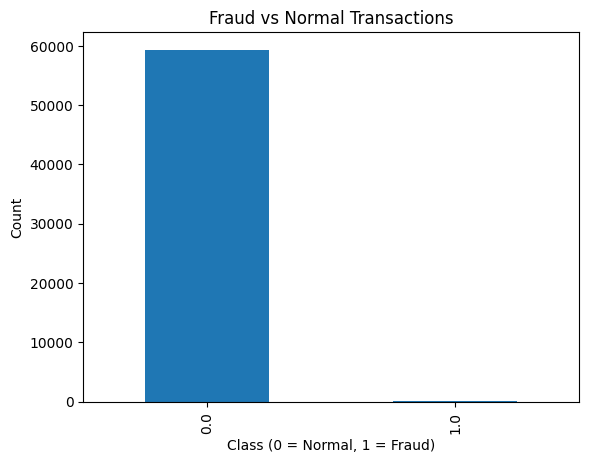

In [5]:
print("\nDataset Info:")
print(data.info())

print("\nClass Distribution:")
print(data["Class"].value_counts())

# Plot fraud vs normal
data["Class"].value_counts().plot(kind="bar")
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

Prepare Data

In [11]:
data.dropna(inplace=True)
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Logistic Regression

In [16]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\n Logistic Regression")

lr_accuracy = accuracy_score(y_test, lr_pred)
print("Accuracy:", lr_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, lr_pred))

lr_roc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])
print("\nROC-AUC Score:", lr_roc)




 Logistic Regression
Accuracy: 0.9985716686271215

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     11874
         1.0       0.79      0.54      0.64        28

    accuracy                           1.00     11902
   macro avg       0.89      0.77      0.82     11902
weighted avg       1.00      1.00      1.00     11902


Confusion Matrix:

[[11870     4]
 [   13    15]]

ROC-AUC Score: 0.9628479992300103


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest")

rf_accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:", rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
print("\nROC-AUC Score:", rf_roc)


Random Forest
Accuracy: 0.9990757855822551

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     11874
         1.0       0.95      0.64      0.77        28

    accuracy                           1.00     11902
   macro avg       0.97      0.82      0.88     11902
weighted avg       1.00      1.00      1.00     11902


Confusion Matrix:

[[11873     1]
 [   10    18]]

ROC-AUC Score: 0.9627276883466878


Model comparisions

In [20]:
from sklearn.metrics import precision_score, recall_score

# Logistic Regression metrics
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)

# Random Forest metrics
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)

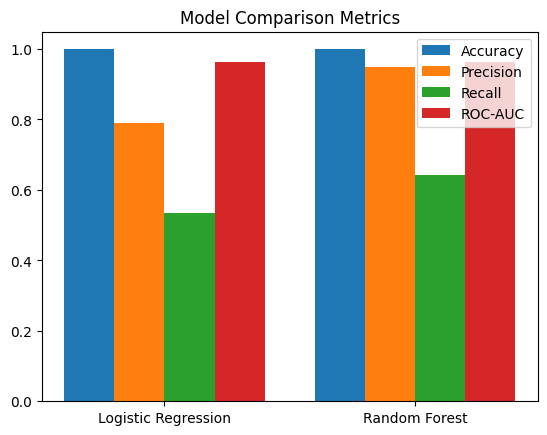

In [21]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "Random Forest"]

accuracy = [lr_accuracy, rf_accuracy]
precision = [lr_precision, rf_precision]
recall = [lr_recall, rf_recall]
roc_auc = [lr_roc, rf_roc]

x = np.arange(len(models))

plt.figure()

plt.bar(x - 0.3, accuracy, width=0.2, label='Accuracy')
plt.bar(x - 0.1, precision, width=0.2, label='Precision')
plt.bar(x + 0.1, recall, width=0.2, label='Recall')
plt.bar(x + 0.3, roc_auc, width=0.2, label='ROC-AUC')

plt.xticks(x, models)
plt.title("Model Comparison Metrics")
plt.legend()

plt.show()

In [22]:

metrics_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "ROC-AUC": [lr_roc, rf_roc]
})

print("\n Metrics Comparison Table \n")
print(metrics_table)


 Metrics Comparison Table 

                 Model  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression  0.998572   0.789474  0.535714  0.962848
1        Random Forest  0.999076   0.947368  0.642857  0.962728


In [23]:
#Fraud Probability
print("\nFraud Probability for first 5 transactions:")
print(rf_model.predict_proba(X_test[:5]))


Fraud Probability for first 5 transactions:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]
